# 题目10：商品评论情感分析

一家电商公司收集了大量用户对其商品的评论和用户的基本信息。为了更好地理解用户情感，并预测用户的满意度，公司希望对这些数据进行深入分析。


#### 第一部分：数据预处理与词云生成准备 (15分)

1. 导入必要库：`pandas`, `jieba`, `re`, `wordcloud`, `matplotlib.pyplot`, `numpy`。（2分）  
2. 读取模拟数据文件 `reviews.csv`（下方提供代码生成），字段为 `review_text`（评论文本）、`sentiment`（真实标签，0=负向，1=正向）。将数据存入变量 `df`。（2分）  
3. 文本清洗函数 `clean_text(text)`：  
   - 去除 URL（如 `http://...` 或 `www.xxx.com`）  
   - 去除邮箱地址  
   - 去除标点符号及特殊字符（保留中文、英文字母、数字）  
   - 去除多余空格（替换连续空格为单个空格，并去掉首尾空格）  
   （请使用 `re.sub` 完成，6分）  
4. 应用清洗函数到 `review_text` 列，生成新列 `cleaned_text`。（2分）  
5. 使用 `jieba.cut` 对 `cleaned_text` 进行精确分词，得到分词列表列 `segmented`。（3分）  


#### 第二部分：机器学习建模 (20分)

6. 导入 `sklearn` 相关模块：`train_test_split`, `TfidfVectorizer`, `MultinomialNB`, `accuracy_score`, `classification_report`。（2分）  
7. 将分词后的列表转回字符串（空格连接），用于向量化：创建列 `text_for_model` = `df['segmented'].apply(lambda x: ' '.join(x))`。（2分）  
8. 使用 `TfidfVectorizer`（参数：`max_features=5000`, `stop_words=['的','了','是','在','我','有']`）对 `text_for_model` 进行向量化。先 `fit_transform` 训练集，再 `transform` 测试集。（6分）  
9. 划分训练集（80%）与测试集（20%），随机种子设为 42。（3分）  
10. 训练 `MultinomialNB()` 模型，拟合训练数据。（3分）  
11. 在测试集上预测，并打印准确率与分类报告（precision, recall, f1-score）。（4分）  

---

#### 第三部分：情感词云可视化 (15分)

12. 根据模型预测结果（非真实标签），筛选出预测为正向（1）和负向（0）的评论。（2分）  
13. 对两类评论的 `cleaned_text` 分别合并成一个大字符串。（2分）  
14. 定义函数 `generate_wordcloud(text, title, filename, colormap)`：  
    - 使用 `WordCloud` 生成词云，要求：  
      - 中文字体：`font_path='simhei.ttf'`（确保系统有该字体，或替换为 `'msyh.ttc'` 等）  
      - 背景色白色 `background_color='white'`  
      - 最大显示词数 100  
      - 使用传入的 `colormap`（如 `'Blues'` 表示冷色系，`'Reds'` 表示暖色系）  
    - 添加标题 `plt.title(title)`  
    - 保存到文件 `filename`（如 `'positive_cloud.png'`）  
    - 显示图像  
    （8分）  
15. 调用函数：  
    - 对正向评论生成词云，标题“正向情感关键词”，保存为 `"positive_cloud.png"`，色系 `'Greens'`  
    - 对负向评论生成词云，标题“负向情感关键词”，保存为 `"negative_cloud.png"`，色系 `'Reds'`  
    （3分）  

In [22]:
import pandas as pd
import random

# 模拟生成500条商品评论数据
random.seed(42)
positive_keywords = ['很好', '喜欢', '推荐', '质量不错', '物流快', '服务好', '性价比高', '超值', '满意', '惊喜']
negative_keywords = ['差评', '垃圾', '失望', '太慢', '客服差', '虚假宣传', '不值', '后悔', '破损', '异味']

reviews = []
labels = []

for _ in range(500):
    if random.random() > 0.5:
        # 正向评论
        base = f"这个商品{random.choice(positive_keywords)}，特别是物流速度非常快，客服也很耐心解答问题。虽然价格稍高，但物有所值！"
        reviews.append(base + " " + f"https://example{random.randint(1,100)}.com")
        labels.append(1)
    else:
        # 负向评论
        base = f"非常{random.choice(negative_keywords)}！物流拖了一周还没到，客服根本不理人。产品和宣传完全不符，简直是诈骗！"
        reviews.append(base + " contact@example.com")
        labels.append(0)

df_sim = pd.DataFrame({
    'review_text': reviews,
    'sentiment': labels
})
df_sim.to_csv(r'csv\reviews.csv', index=False, encoding='utf-8')
print("✅ 模拟数据 reviews.csv 已生成！")

✅ 模拟数据 reviews.csv 已生成！


读取模拟数据文件 `reviews.csv`（下方提供代码生成），字段为 `review_text`（评论文本）、`sentiment`（真实标签，0=负向，1=正向）。将数据存入变量 `df`

In [ ]:
df = pd.read_csv(r'csv\reviews.csv', encoding='utf-8')

构建文本清洗函数 `clean_text(text)`：  
   - 去除 URL（如 `http://...` 或 `www.xxx.com`）  
   - 去除邮箱地址  
   - 去除标点符号及特殊字符（保留中文、英文字母、数字）  
   - 去除多余空格（替换连续空格为单个空格，并去掉首尾空格）  

In [ ]:
import re

def clean_text(text):
    # 去除 url
    text = re.sub(r'https?://.*\.com|www\..*\.com', '', text)
    # 去除邮箱地址
    text = re.sub(r'\b\w*@\w*.com\b', '', text)
    # 保留中文、英文字母、数字 --- 去除标点符号
    text = re.sub(r'[，。？；‘“”’！,.?;:\'\"{}]+', '', text)
    # 去除多余空格
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    
    return text

应用清洗函数到 `review_text` 列，生成新列 `cleaned_text`

In [34]:
df['cleaned_text'] = df['review_text'].apply(clean_text)
df['cleaned_text'].head()

0    这个商品很好特别是物流速度非常快客服也很耐心解答问题虽然价格稍高但物有所值 
1       非常太慢物流拖了一周还没到客服根本不理人产品和宣传完全不符简直是诈骗 
2       非常垃圾物流拖了一周还没到客服根本不理人产品和宣传完全不符简直是诈骗 
3    这个商品满意特别是物流速度非常快客服也很耐心解答问题虽然价格稍高但物有所值 
4    这个商品很好特别是物流速度非常快客服也很耐心解答问题虽然价格稍高但物有所值 
Name: cleaned_text, dtype: object

使用 `jieba.cut` 对 `cleaned_text` 进行精确分词，得到分词列表列 `segmented`

In [36]:
import jieba
def cut(text):
    return jieba.lcut(text,cut_all=False)

df['segmented'] = df['cleaned_text'].apply(cut)
df['segmented'].head()

0    [这个, 商品, 很, 好, 特别, 是, 物流, 速度, 非常, 快, 客服, 也, 很,...
1    [非常, 太慢, 物流, 拖, 了, 一周, 还, 没到, 客服, 根本, 不理, 人, 产...
2    [非常, 垃圾, 物流, 拖, 了, 一周, 还, 没到, 客服, 根本, 不理, 人, 产...
3    [这个, 商品, 满意, 特别, 是, 物流, 速度, 非常, 快, 客服, 也, 很, 耐...
4    [这个, 商品, 很, 好, 特别, 是, 物流, 速度, 非常, 快, 客服, 也, 很,...
Name: segmented, dtype: object

In [37]:
#  导入 `sklearn` 相关模块：`train_test_split`, `TfidfVectorizer`, `MultinomialNB`, `accuracy_score`, `classification_report`
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report



In [38]:
# # 将分词后的列表转回字符串（空格连接），用于向量化：创建列 `text_for_model` = `df['segmented'].apply(lambda x: ' '.join(x))`
df['text_for_model'] = df['segmented'].apply(lambda a: ' '.join(a))
df['text_for_model'].head()

0    这个 商品 很 好 特别 是 物流 速度 非常 快 客服 也 很 耐心 解答 问题 虽然 价...
1    非常 太慢 物流 拖 了 一周 还 没到 客服 根本 不理 人 产品 和 宣传 完全 不符 ...
2    非常 垃圾 物流 拖 了 一周 还 没到 客服 根本 不理 人 产品 和 宣传 完全 不符 ...
3    这个 商品 满意 特别 是 物流 速度 非常 快 客服 也 很 耐心 解答 问题 虽然 价格...
4    这个 商品 很 好 特别 是 物流 速度 非常 快 客服 也 很 耐心 解答 问题 虽然 价...
Name: text_for_model, dtype: object

In [40]:
x_train, x_test, y_train, y_test = train_test_split(df['text_for_model'], df['sentiment'], test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000, stop_words=['的','了','是','在','我','有'])
x_train = vectorizer.fit_transform(x_train)
x_test = vectorizer.transform(x_test)



nomialnb = MultinomialNB()
nomialnb.fit(x_train, y_train)
y_pred = nomialnb.predict(x_test)

print(f"准确率: {accuracy_score(y_test, y_pred)}")
print("分类报告:")
print(classification_report(y_test, y_pred))



准确率: 1.0
分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        54

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [53]:
#  根据模型预测结果（非真实标签），筛选出预测为正向（1）和负向（0）的评论
index = y_test.index
df['pred_sentiment'] = df['sentiment']
df.loc[index, 'pred_sentiment'] = y_pred

postive = ' '.join(df.loc[df['pred_sentiment'] == 1, 'cleaned_text'].to_list())
negative = ' '.join(df.loc[df['pred_sentiment'] == 0, 'cleaned_text'].to_list())

In [56]:
import wordcloud
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

def generate_wordcloud(text, title, filename, colormap):
    wc = wordcloud.WordCloud(font_path='simhei.ttf',
                             background_color='white',
                             max_words=100,
                             colormap=colormap,
                             )
    word_cloud = wc.generate(text)
    
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.imshow(word_cloud, interpolation='bilinear')
    plt.axis('off')
    plt.savefig(filename)
    plt.show()



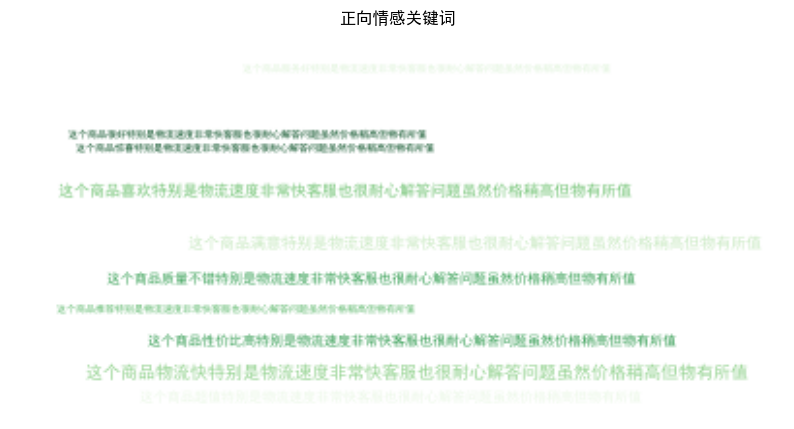

In [57]:
generate_wordcloud(postive, '正向情感关键词', r'png/positive_cloud.png', colormap='Greens')

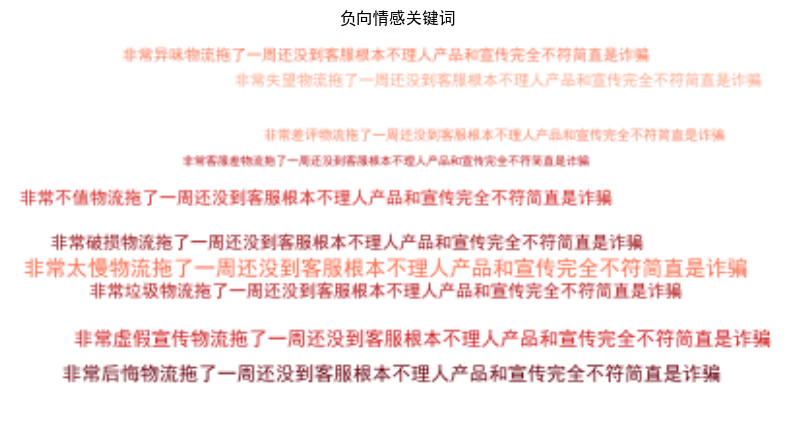

In [58]:
generate_wordcloud(negative, '负向情感关键词', r'png/negative_cloud.png', colormap='Reds')

12. 根据模型预测结果（非真实标签），筛选出预测为正向（1）和负向（0）的评论。（2分）  
13. 对两类评论的 `cleaned_text` 分别合并成一个大字符串。（2分）  
14. 定义函数 `generate_wordcloud(text, title, filename, colormap)`：  
    - 使用 `WordCloud` 生成词云，要求：  
      - 中文字体：`font_path='simhei.ttf'`（确保系统有该字体，或替换为 `'msyh.ttc'` 等）  
      - 背景色白色 `background_color='white'`  
      - 最大显示词数 100  
      - 使用传入的 `colormap`（如 `'Blues'` 表示冷色系，`'Reds'` 表示暖色系）  
    - 添加标题 `plt.title(title)`  
    - 保存到文件 `filename`（如 `'positive_cloud.png'`）  
    - 显示图像  
    （8分）  
15. 调用函数：  
    - 对正向评论生成词云，标题“正向情感关键词”，保存为 `"positive_cloud.png"`，色系 `'Greens'`  
    - 对负向评论生成词云，标题“负向情感关键词”，保存为 `"negative_cloud.png"`，色系 `'Reds'`  
    （3分）  

# 题目 11： 自动化文档处理

使用 Python 读取并自动化处理一份包含表格和段落的 Word 文档，完成内容提取、修改、统计与格式化保存。

【任务】  

1. 使用合适的命令导入 `python-docx` 库（2分）  
   - 要求：仅导入必要模块，禁止导入未使用的库

2. 打开【data_A】文件夹中的【2024年销售季度报告.docx】文档，遍历并打印所有**非空段落**的文本内容（4分）  
   - 提示：跳过 text 为空的段落（如仅有换行或空白字符）

3. 统计并按格式打印：
   - 文档总段落数（含空段落）
   - 非空段落数
   - 总字符数（含标点、数字、空格）
   - 表格总数
   - 所有表格中单元格总数（5分）  
   【参考打印格式】  
   ```
   总段落数: []
   非空段落数: []
   总字符数: []
   表格总数: []
   单元格总数: []
   ```

4. 将文档中所有出现的“销售额”替换为“Revenue（销售额）”，要求在保留原格式（加粗/斜体）前提下替换（6分）  
   - 注意：不能直接替换整个段落.text，需遍历每个 `Run` 对象进行局部替换
   - 替换后打印所有被修改段落的完整文本（用于验证）

5. 在**每张表格下方插入新段落**，内容为：“表 [n]：数据来源内部系统”，其中 n 为当前表格序号（从1开始）；该段落字体加粗、居中对齐（7分）  
   - 要求：使用 `WD_ALIGN_PARAGRAPH.CENTER` 设置对齐方式
   - 要求：使用 `bold = True` 设置加粗

6. 在文档末尾添加标题“附录：数据汇总”，级别为 level=1，并紧接着添加一个 3×4 的空表格（列名：项目、Q1、Q2、Q3），设置第一行为灰色底纹（RGB(200,200,200)）（8分）  
   - 提示：使用 `add_heading`, `add_table`, `rows[0].cells[i]._element.get_or_add_tcPr().append(...)` 设置背景色

7. 将最终处理后的文档另存为【output_A】文件夹中的【2024_销售报告_修订版.docx】（4分）  

8. 每完成一个主要任务（第2～6问）后，打印一行由 50 个 “=” 组成的分隔线（如：==================================================）以划分输出区块（4分）

【备注】  
- 正确输出结构可参考【refer_A/第五题.txt】文件。
- 原始文档包含3个表格、若干带格式段落、部分段落含“销售额”关键词。
- 表格内可能也包含“销售额”文字，但也需要被替换。
- 替换时若原文本加粗，“Revenue（销售额）”也必须保持加粗。

【加分挑战】 ✅  
- 若能在替换“销售额”时，自动记录替换次数并在最后打印：“共执行 [x] 处文本替换”，额外加3分。

In [ ]:
# 模拟数据生成

from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

# 创建模拟文档用于练习
doc = Document()

# 添加标题与带格式段落
doc.add_heading('2024年第一季度销售总结', level=1)
p1 = doc.add_paragraph()
p1.add_run('本季度 ').bold = True
p1.add_run('销售额').italic = True
p1.add_run(' 同比增长15%。')

p2 = doc.add_paragraph('华东区销售额最高，其次是华南区。')
p2.alignment = WD_ALIGN_PARAGRAPH.RIGHT

doc.add_paragraph()  # 空段落

# 添加第一个表格
table1 = doc.add_table(rows=3, cols=3)
table1.style = 'Table Grid'
headers = ["区域", "销售额", "增长率"]
for i, header in enumerate(headers):
    table1.cell(0, i).text = header
    table1.cell(0, i).paragraphs[0].runs[0].bold = True
table1.cell(1, 0).text = "华东"
table1.cell(1, 1).text = "¥500万"
table1.cell(1, 2).text = "15%"
table1.cell(2, 0).text = "华南"
table1.cell(2, 1).text = "¥420万"
table1.cell(2, 2).text = "12%"

# 添加第二个表格略...

doc.add_paragraph('年度销售额目标已调整为 ¥3000万。').italic = True

# 保存原始文档
doc.save('docx/2024年销售季度报告.docx')
print("✅ 模拟文档已生成于 data_A/2024年销售季度报告.docx")


✅ 模拟文档已生成于 data_A/2024年销售季度报告.docx


In [65]:
import docx

doc = docx.Document(r'docx\2024年销售季度报告.docx')

paragraphs = doc.paragraphs
nonan_para = 0

char_num = 0
for paragraph in paragraphs:
    if paragraph.text.strip() != '':
        print(paragraph.text)
        char_num += len(paragraph.text)
    else:
        continue
        
    nonan_para += 1

ele_num = 0
for table in doc.tables:
    ele_num += len(table.rows) * len(table.columns)


2024年第一季度销售总结
本季度 销售额 同比增长15%。
华东区销售额最高，其次是华南区。
年度销售额目标已调整为 ¥3000万。


In [66]:
print(f"""
总段落数: [{len(paragraphs)}]
非空段落数: [{nonan_para}]
总字符数: [{char_num}]
表格总数: [{len(doc.tables)}]
单元格总数: [{ele_num}]
""")


总段落数: [5]
非空段落数: [4]
总字符数: [64]
表格总数: [1]
单元格总数: [9]



将文档中所有出现的“销售额”替换为“Revenue（销售额）”，要求在保留原格式（加粗/斜体）前提下替换（6分）  
   - 注意：不能直接替换整个段落.text，需遍历每个 `Run` 对象进行局部替换
   - 替换后打印所有被修改段落的完整文本（用于验证）

In [67]:
for paragraph in paragraphs:
    for run in paragraph.runs:
        if "销售额" in run.text:
            run.text = run.text.replace("销售额", "Revenue（销售额）")
        
            print(paragraph.text)

本季度 Revenue（销售额） 同比增长15%。
华东区Revenue（销售额）最高，其次是华南区。
年度Revenue（销售额）目标已调整为 ¥3000万。


在**每张表格下方插入新段落**，内容为：“表 [n]：数据来源内部系统”，其中 n 为当前表格序号（从1开始）；该段落字体加粗、居中对齐（7分）  
   - 要求：使用 `WD_ALIGN_PARAGRAPH.CENTER` 设置对齐方式
   - 要求：使用 `bold = True` 设置加粗

将最终处理后的文档另存为【output_A】文件夹中的【2024_销售报告_修订版.docx】

In [70]:
doc.save(r"docx/2024_销售报告_修订版.docx")

In [73]:
def traverse_tables(doc_path: str):
    """遍历文档中的所有表格"""
    doc = Document(doc_path)
    
    print("=" * 50)
    print("📊 表格遍历")
    print("=" * 50)
    
    for table_idx, table in enumerate(doc.tables, 1):
        print(f"\n📋 表格 {table_idx}:")
        print(f"   行数: {len(table.rows)}")
        print(f"   列数: {len(table.columns)}")
        
        # 遍历所有行
        for row_idx, row in enumerate(table.rows, 1):
            print(f"\n   📍 第 {row_idx} 行:")
            
            # 遍历行中的所有单元格
            for cell_idx, cell in enumerate(row.cells, 1):
                cell_text = cell.text.strip()
                print(f"      📦 单元格[{row_idx},{cell_idx}]: '{cell_text}'")
                
                # 遍历单元格中的段落（单元格内可能有多个段落）
                if cell.paragraphs:
                    for para_idx, para in enumerate(cell.paragraphs, 1):
                        if para.text.strip():  # 只显示非空段落
                            print(f"        段落 {para_idx}: '{para.text}'")

traverse_tables(r"docx/2024_销售报告_修订版.docx")

📊 表格遍历

📋 表格 1:
   行数: 3
   列数: 3

   📍 第 1 行:
      📦 单元格[1,1]: '区域'
        段落 1: '区域'
      📦 单元格[1,2]: '销售额'
        段落 1: '销售额'
      📦 单元格[1,3]: '增长率'
        段落 1: '增长率'

   📍 第 2 行:
      📦 单元格[2,1]: '华东'
        段落 1: '华东'
      📦 单元格[2,2]: '¥500万'
        段落 1: '¥500万'
      📦 单元格[2,3]: '15%'
        段落 1: '15%'

   📍 第 3 行:
      📦 单元格[3,1]: '华南'
        段落 1: '华南'
      📦 单元格[3,2]: '¥420万'
        段落 1: '¥420万'
      📦 单元格[3,3]: '12%'
        段落 1: '12%'


# 题目11：数据清洗

处理一个包含客户交易信息的CSV文件（customer_transactions.csv），针对不同列的缺失值进行填充操作。填充的方式包括使用特定方法填充某些列，使用条件填充某些特定的情况，最后将处理后的数据保存为新的CSV文件。

【任务】  
1. 导入Pandas库，并读取【data_A】目录下的【customer_transactions.csv】表格数据，将读取的结果存储在变量df中（4分）
2. 针对交易日期（transaction_date）列的缺失值，使用该列的众数进行填充（4分）
3. 针对客户名称（customer_name）列的缺失值，使用该列的上一个有效值填充下一个缺失值（4分）
4. 针对金额（amount）列，当订单状态（order_status）为"completed"时，如果该金额为空，则用该客户的平均交易金额（不包含缺失值）填充；否则用0填充（5分）
5. 针对支付方式（payment_method）列的缺失值，如果该客户的其他记录中有支付方式，则使用该支付方式填充；否则填充为"unknown"（5分）
6. 将填充后的数据保存为output_A文件夹下的filled_customer_transactions.csv文件，要求不保存DataFrame的index索引，且在Excel中打开不会出现中文乱码（6分）

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('csv/customer_transactions.csv', encoding='utf-8')

df['transaction_date'] = df['transaction_date'].fillna(df['transaction_date'].mode()[0])

df['customer_name'] = df['customer_name'].ffill(axis=0)

amount_mean = df.groupby('customer_name')['amount'].mean().fillna(0)
def fill_amount(data):
    if pd.isna(data['amount']) and data['order_status'] == 'completed':
        return amount_mean.get(data['customer_name'], 0)
    elif pd.isna(data['amount']):
        return 0
    return data['amount']
    
df['amount'] = df.apply(fill_amount, axis=1)
print(df['amount'].info(), '\n')




<class 'pandas.core.series.Series'>
RangeIndex: 200 entries, 0 to 199
Series name: amount
Non-Null Count  Dtype  
--------------  -----  
200 non-null    float64
dtypes: float64(1)
memory usage: 1.7 KB
None 



In [3]:
# 针对支付方式（payment_method）列的缺失值，如果该客户的其他记录中有支付方式，则使用该支付方式填充；否则填充为"unknown"


pay_method = df.groupby('customer_name')['payment_method'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else "unknown"
)

pay_method = pay_method.to_dict()

def fill_payment_method(data):
    if pd.isna(data['payment_method']):
        return pay_method.get(data['customer_name'], 'unknown')

    return data['payment_method']

df['payment_method'] = df.apply(fill_payment_method, axis=1)

df['payment_method'].info()


<class 'pandas.core.series.Series'>
RangeIndex: 200 entries, 0 to 199
Series name: payment_method
Non-Null Count  Dtype 
--------------  ----- 
200 non-null    object
dtypes: object(1)
memory usage: 1.7+ KB


In [4]:
df.to_csv(r"csv/filled_customer_transactions.csv", index=False, encoding='utf-8')